# Task 1 Architecture Search

## Objective
Find the optimal block subset for **Task 1** via exhaustive search over all non-empty subsets.

## Setup
- **State blocks:** b1 (1-dim), b2 (1-dim), b3 (1-dim), b4 (2-dim)
- **Architecture space:** all non-empty subsets of {b1, b2, b3, b4} → **2⁴ − 1 = 15** architectures
- **Ground truth for Task 1:** `reward = b1 + sin(b2)` → should use **b1** and **b2**
- **Training:** each architecture is trained independently with RL (Contextual Bandit)
- **Evaluation metric:** MSE between predicted Q-value and true reward

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from typing import Dict, List
from collections import deque
import random
from tqdm import tqdm
import os

# Device configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[Device] Using: {DEVICE}")

np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

print("[OK] All libraries imported")

[Device] Using: cuda
[OK] All libraries imported


## 1. RL Environment (Task 1 only)

In [24]:
class RLEnvironment:
    """Contextual Bandit environment for Task 1.

    State  : [b1, b2, b3, b4x, b4y]  (5-dim)
    Reward : b1 + sin(b2)             (depends only on b1 and b2)
    """

    def reset(self):
        """Sample a new state and return it as a CPU tensor."""
        self.state = {
            'b1': np.random.uniform(-1, 1),
            'b2': np.random.uniform(0, 2 * np.pi),
            'b3': np.random.randint(0, 2),
            'b4': np.random.uniform(-1, 1, size=2)
        }
        return torch.tensor([
            self.state['b1'],
            self.state['b2'],
            float(self.state['b3']),
            self.state['b4'][0],
            self.state['b4'][1]
        ], dtype=torch.float32)

    def step(self):
        """Return the Task 1 reward for the current state."""
        return float(self.state['b1'] + np.sin(self.state['b2']))


env = RLEnvironment()

# Quick sanity check
state = env.reset()
reward = env.step()
print(f"[OK] Environment created")
print(f"     Sample state : {state.numpy()}")
print(f"     Sample reward: {reward:.4f}")

[OK] Environment created
     Sample state : [-0.25091976  5.973514    0.          0.559382    0.19370031]
     Sample reward: -0.5557


## 2. Replay Buffer

In [25]:
class ReplayBuffer:
    """Fixed-capacity experience replay buffer.

    States are stored on CPU; the entire batch is moved to DEVICE on sample.
    """

    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state: torch.Tensor, reward: float):
        self.buffer.append((state, float(reward)))

    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        states, rewards = zip(*batch)
        return (
            torch.stack(states).to(DEVICE),
            torch.tensor(rewards, dtype=torch.float32, device=DEVICE)
        )

    def __len__(self):
        return len(self.buffer)


print("[OK] ReplayBuffer defined")

[OK] ReplayBuffer defined


## 3. Modular Q-Network

Each architecture is defined by a **binary mask** over the 4 blocks.
Only the selected blocks are passed through their `BlockModule` and concatenated
before the task head.

```
state [5-dim]
  → extract_blocks → [b1(1), b2(1), b3(1), b4(2)]
  → selected BlockModules → concat
  → Linear head → scalar Q-value
```

In [26]:
# Input dimensions for each block
BLOCK_DIMS = [1, 1, 1, 2]   # b1, b2, b3, b4
BLOCK_NAMES = ['b1', 'b2', 'b3', 'b4']


class BlockModule(nn.Module):
    """Small MLP that encodes one state block into an 8-dim feature vector."""

    def __init__(self, input_dim: int, hidden_dim: int = 16, output_dim: int = 8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class ModularQNetwork(nn.Module):
    """Q-Network whose input is determined by a block selection mask.

    Parameters
    ----------
    block_mask : list of int
        Indices of the blocks used by this architecture, e.g. [0, 1] for b1+b2.
    module_output_dim : int
        Output dimension of each BlockModule (default 8).
    """

    def __init__(self, block_mask: List[int], module_output_dim: int = 8):
        super().__init__()
        self.block_mask = block_mask
        self.module_output_dim = module_output_dim

        # Create one BlockModule per selected block
        self.block_modules = nn.ModuleList([
            BlockModule(BLOCK_DIMS[i], hidden_dim=16, output_dim=module_output_dim)
            for i in block_mask
        ])

        # Linear head: concat(selected block outputs) -> scalar
        self.head = nn.Linear(len(block_mask) * module_output_dim, 1)

    def extract_blocks(self, x: torch.Tensor) -> List[torch.Tensor]:
        """Slice the full 5-dim state into the 4 block tensors."""
        if x.dim() == 1:
            x = x.unsqueeze(0)
        all_blocks = [x[:, 0:1], x[:, 1:2], x[:, 2:3], x[:, 3:5]]
        return [all_blocks[i] for i in self.block_mask]

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass for a batch of states. Returns scalar Q-values."""
        blocks = self.extract_blocks(x)
        features = [m(b) for m, b in zip(self.block_modules, blocks)]
        h = torch.cat(features, dim=1)
        return self.head(h).squeeze(-1)


print("[OK] BlockModule and ModularQNetwork defined")

[OK] BlockModule and ModularQNetwork defined


## 4. Architecture Space

Generate all **15 non-empty subsets** of {b1, b2, b3, b4} using binary enumeration.

| Integer | Binary | Selected blocks |
|---------|--------|-----------------|
| 1       | 0001   | b1              |
| 2       | 0010   | b2              |
| 3       | 0011   | b1, b2 ← Ground Truth |
| ...     | ...    | ...             |
| 15      | 1111   | b1, b2, b3, b4  |

In [27]:
def generate_all_architectures(n_blocks: int = 4) -> List[List[int]]:
    """Return all non-empty subsets of block indices as sorted lists."""
    architectures = []
    for mask in range(1, 2 ** n_blocks):   # 1 to 15, skipping 0 (empty set)
        selected = [i for i in range(n_blocks) if (mask >> i) & 1]
        architectures.append(selected)
    return architectures


def mask_to_string(block_mask: List[int]) -> str:
    """Human-readable name for an architecture, e.g. [0,1] -> 'b1+b2'."""
    return '+'.join(BLOCK_NAMES[i] for i in block_mask)


GROUND_TRUTH_MASK = [0, 1]   # b1 and b2

all_architectures = generate_all_architectures(n_blocks=4)

print(f"[OK] Architecture space: {len(all_architectures)} non-empty subsets")
print(f"\nAll architectures:")
for i, arch in enumerate(all_architectures):
    gt_marker = ' <- Ground Truth' if arch == GROUND_TRUTH_MASK else ''
    print(f"  {i+1:2d}. {mask_to_string(arch):<20}{gt_marker}")

[OK] Architecture space: 15 non-empty subsets

All architectures:
   1. b1                  
   2. b2                  
   3. b1+b2                <- Ground Truth
   4. b3                  
   5. b1+b3               
   6. b2+b3               
   7. b1+b2+b3            
   8. b4                  
   9. b1+b4               
  10. b2+b4               
  11. b1+b2+b4            
  12. b3+b4               
  13. b1+b3+b4            
  14. b2+b3+b4            
  15. b1+b2+b3+b4         


## 5. RL Training Function

**Optimizations vs. naive loop:**
- Entire batch is forwarded in one call (no per-sample loop)
- `MSELoss` computed over the full batch tensor
- Single device transfer per sample step

In [ ]:
def train_with_rl(
    model: ModularQNetwork,
    env: RLEnvironment,
    n_episodes: int = 1000,
    batch_size: int = 256,
    lr: float = 1e-3,
    verbose: bool = False
) -> Dict:
    """Train model with TD Learning + Experience Replay (Contextual Bandit).

    Because this is a single-step MDP, the TD target equals the immediate reward:
        target_Q = reward   (no discount term)
    """
    model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    replay_buffer = ReplayBuffer(capacity=10000)

    episode_rewards = []
    losses = []

    pbar = tqdm(range(n_episodes), desc="Training", leave=False, disable=not verbose)

    for episode in pbar:
        # --- Interaction ---
        state = env.reset()          # CPU tensor
        reward = env.step()
        replay_buffer.push(state, reward)
        episode_rewards.append(reward)

        # --- Learning ---
        if len(replay_buffer) >= batch_size:
            batch_states, batch_rewards = replay_buffer.sample(batch_size)

            model.train()
            optimizer.zero_grad()

            pred_qs = model(batch_states)          # (batch_size,)
            loss = criterion(pred_qs, batch_rewards)

            loss.backward()
            optimizer.step()

            losses.append(loss.item())
            if verbose:
                pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    pbar.close()
    return {'episode_rewards': episode_rewards, 'losses': losses}


print("[OK] train_with_rl defined")

[OK] train_with_rl defined


## 6. Architecture Evaluation Function

For each architecture:
1. Build a fresh `ModularQNetwork` with that block mask
2. Train it for `n_episodes`
3. Evaluate on `n_eval_episodes` new states → return average MSE

In [29]:
def evaluate_architecture(
    block_mask: List[int],
    env: RLEnvironment,
    n_episodes: int = 2000,
    n_eval_episodes: int = 500,
    n_runs: int = 5,
    verbose: bool = False
) -> Dict:
    """Train and evaluate one architecture over multiple runs. Returns mean MSE.

    Running multiple independent trials and averaging reduces the variance caused
    by random initialization and sampling, so the search reliably finds the true
    best architecture rather than a lucky outlier.
    """
    run_mses = []

    for run in range(n_runs):
        # Fresh model and training for each run (different random state)
        model = ModularQNetwork(block_mask).to(DEVICE)
        train_with_rl(model, env, n_episodes=n_episodes, verbose=verbose)

        model.eval()
        sq_errors = []
        with torch.no_grad():
            for _ in range(n_eval_episodes):
                state = env.reset().to(DEVICE)
                true_reward = env.step()
                pred_q = model(state).item()
                sq_errors.append((pred_q - true_reward) ** 2)

        run_mses.append(float(np.mean(sq_errors)))

    avg_mse = float(np.mean(run_mses))
    std_mse = float(np.std(run_mses))

    return {
        'block_mask': block_mask,
        'name': mask_to_string(block_mask),
        'mse': avg_mse,
        'mse_std': std_mse,
        'run_mses': run_mses,
        'is_ground_truth': block_mask == GROUND_TRUTH_MASK,
        'history': None   # not tracked across multiple runs
    }


print("[OK] evaluate_architecture defined (multi-run averaging)")

[OK] evaluate_architecture defined (multi-run averaging)


## 7. Exhaustive Search over All 15 Architectures

In [30]:
N_EPISODES     = 2000   # training episodes per architecture per run
N_EVAL         = 500    # evaluation episodes per architecture per run
N_RUNS         = 5      # independent runs to average (reduces variance)

print("=" * 70)
print(f"Exhaustive search: {len(all_architectures)} architectures")
print(f"Training episodes per arch : {N_EPISODES}")
print(f"Evaluation episodes per arch: {N_EVAL}")
print(f"Independent runs per arch  : {N_RUNS}  (MSE = mean over runs)")
print("=" * 70)

results = []

for arch in tqdm(all_architectures, desc="Searching"):
    result = evaluate_architecture(
        arch, env,
        n_episodes=N_EPISODES,
        n_eval_episodes=N_EVAL,
        n_runs=N_RUNS
    )
    results.append(result)
    gt_marker = ' [GT]' if result['is_ground_truth'] else ''
    tqdm.write(
        f"  {result['name']:<20} MSE = {result['mse']:.6f} ± {result['mse_std']:.6f}{gt_marker}"
    )

print("\n[OK] Search complete")

Exhaustive search: 15 architectures
Training episodes per arch : 2000
Evaluation episodes per arch: 500
Independent runs per arch  : 5  (MSE = mean over runs)


Searching:   7%|▋         | 1/15 [00:14<03:26, 14.74s/it]

  b1                   MSE = 0.508203 ± 0.017604


Searching:  13%|█▎        | 2/15 [00:31<03:30, 16.21s/it]

  b2                   MSE = 0.362397 ± 0.028358


...

  b1+b3+b4             MSE = 0.487192 ± 0.018570


Searching:  93%|█████████▎| 14/15 [04:00<00:18, 18.55s/it]

  b2+b3+b4             MSE = 0.429491 ± 0.060434


Searching: 100%|██████████| 15/15 [04:24<00:00, 17.62s/it]

  b1+b2+b3+b4          MSE = 0.057921 ± 0.067858

[OK] Search complete


## 8. Results Summary

In [31]:
# Sort by MSE (ascending)
sorted_results = sorted(results, key=lambda r: r['mse'])
best = sorted_results[0]
gt_result = next(r for r in results if r['is_ground_truth'])

print("=" * 70)
print("All Architectures Ranked by MSE (mean ± std over runs)")
print("=" * 70)
print(f"{'Rank':<5} {'Architecture':<22} {'MSE':>10}  {'Std':>10}  {'GT?':>5}")
print("-" * 60)
for rank, r in enumerate(sorted_results, 1):
    gt_marker = '  *' if r['is_ground_truth'] else ''
    print(f"{rank:<5} {r['name']:<22} {r['mse']:>10.6f}  {r['mse_std']:>10.6f}{gt_marker}")

print("\n" + "=" * 70)
print("Summary")
print("=" * 70)
print(f"  Best architecture : {best['name']}  (MSE = {best['mse']:.6f} ± {best['mse_std']:.6f})")
print(f"  Ground truth      : {gt_result['name']}  (MSE = {gt_result['mse']:.6f} ± {gt_result['mse_std']:.6f})")
print(f"  Ground truth rank : {sorted_results.index(gt_result) + 1} / {len(sorted_results)}")
print(f"  Search found GT?  : {best['is_ground_truth']}")

All Architectures Ranked by MSE (mean ± std over runs)
Rank  Architecture                  MSE         Std    GT?
------------------------------------------------------------
1     b1+b2+b3                 0.027981    0.048862
2     b1+b2+b4                 0.032932    0.059903
3     b1+b2+b3+b4              0.057921    0.067858
4     b1+b2                    0.082814    0.065259  *
5     b2+b3                    0.361147    0.034081
6     b2                       0.362397    0.028358
7     b2+b4                    0.401042    0.075937
8     b2+b3+b4                 0.429491    0.060434
9     b1+b3+b4                 0.487192    0.018570
10    b1+b3                    0.502916    0.013048
11    b1                       0.508203    0.017604
12    b1+b4                    0.513433    0.019471
13    b3                       0.831805    0.058063
14    b4                       0.836836    0.051027
15    b3+b4                    0.840061    0.020228

Summary
  Best architecture : b1+b2+b3  (

## 9. Visualize Results

[OK] Saved: results_diagram/task1_arch_search.png


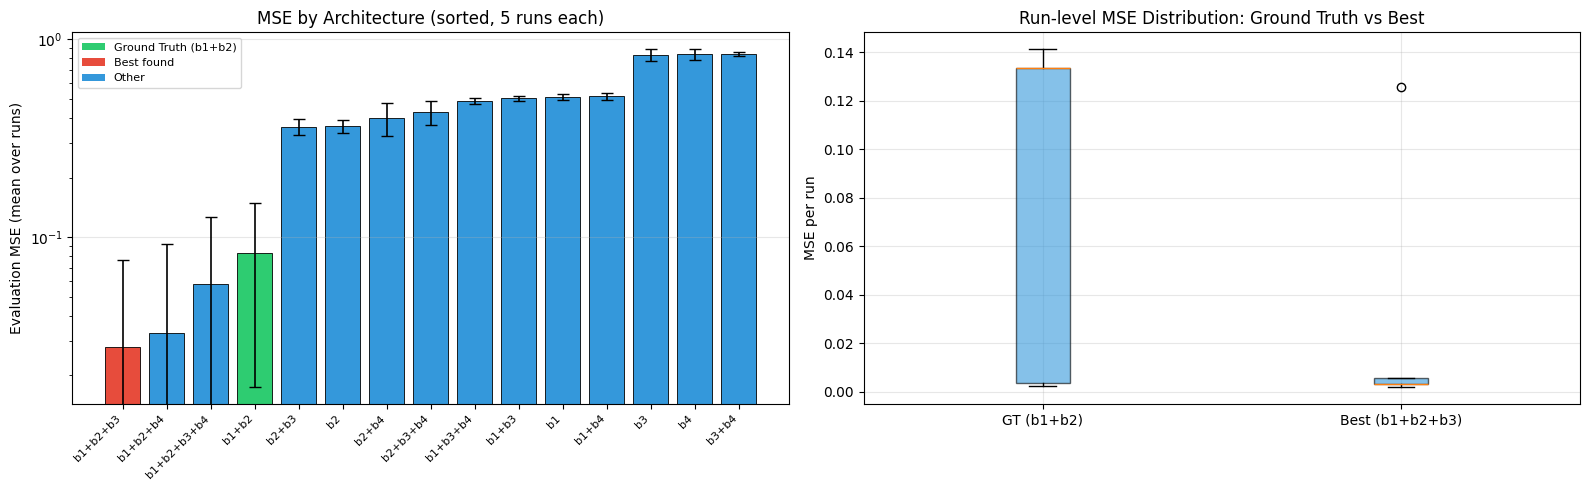

In [32]:
os.makedirs('results_diagram', exist_ok=True)

names  = [r['name'] for r in sorted_results]
mses   = [r['mse']  for r in sorted_results]
stds   = [r['mse_std'] for r in sorted_results]
colors = ['#2ecc71' if r['is_ground_truth'] else
          '#e74c3c' if r == best else '#3498db'
          for r in sorted_results]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: bar chart of all architectures with error bars ---
ax = axes[0]
bars = ax.bar(range(len(names)), mses, color=colors, edgecolor='black', linewidth=0.6)
ax.errorbar(range(len(names)), mses, yerr=stds, fmt='none', color='black',
            capsize=4, linewidth=1.2, label='±std over runs')
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Evaluation MSE (mean over runs)')
ax.set_title(f'MSE by Architecture (sorted, {N_RUNS} runs each)')
ax.set_yscale('log')
ax.grid(True, axis='y', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Ground Truth (b1+b2)'),
    Patch(facecolor='#e74c3c', label='Best found'),
    Patch(facecolor='#3498db', label='Other'),
]
ax.legend(handles=legend_elements, fontsize=8)

# --- Right: per-run MSE distribution for ground truth vs best ---
ax = axes[1]
ax.boxplot(
    [gt_result['run_mses'], best['run_mses']],
    labels=[f"GT ({gt_result['name']})", f"Best ({best['name']})"],
    patch_artist=True,
    boxprops=dict(facecolor='#3498db', alpha=0.6)
)
ax.set_ylabel('MSE per run')
ax.set_title('Run-level MSE Distribution: Ground Truth vs Best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results_diagram/task1_arch_search.png', dpi=150, bbox_inches='tight')
print("[OK] Saved: results_diagram/task1_arch_search.png")
plt.show()

## 10. Training Loss Curves — All Architectures

[OK] Saved: results_diagram/task1_all_loss_curves.png


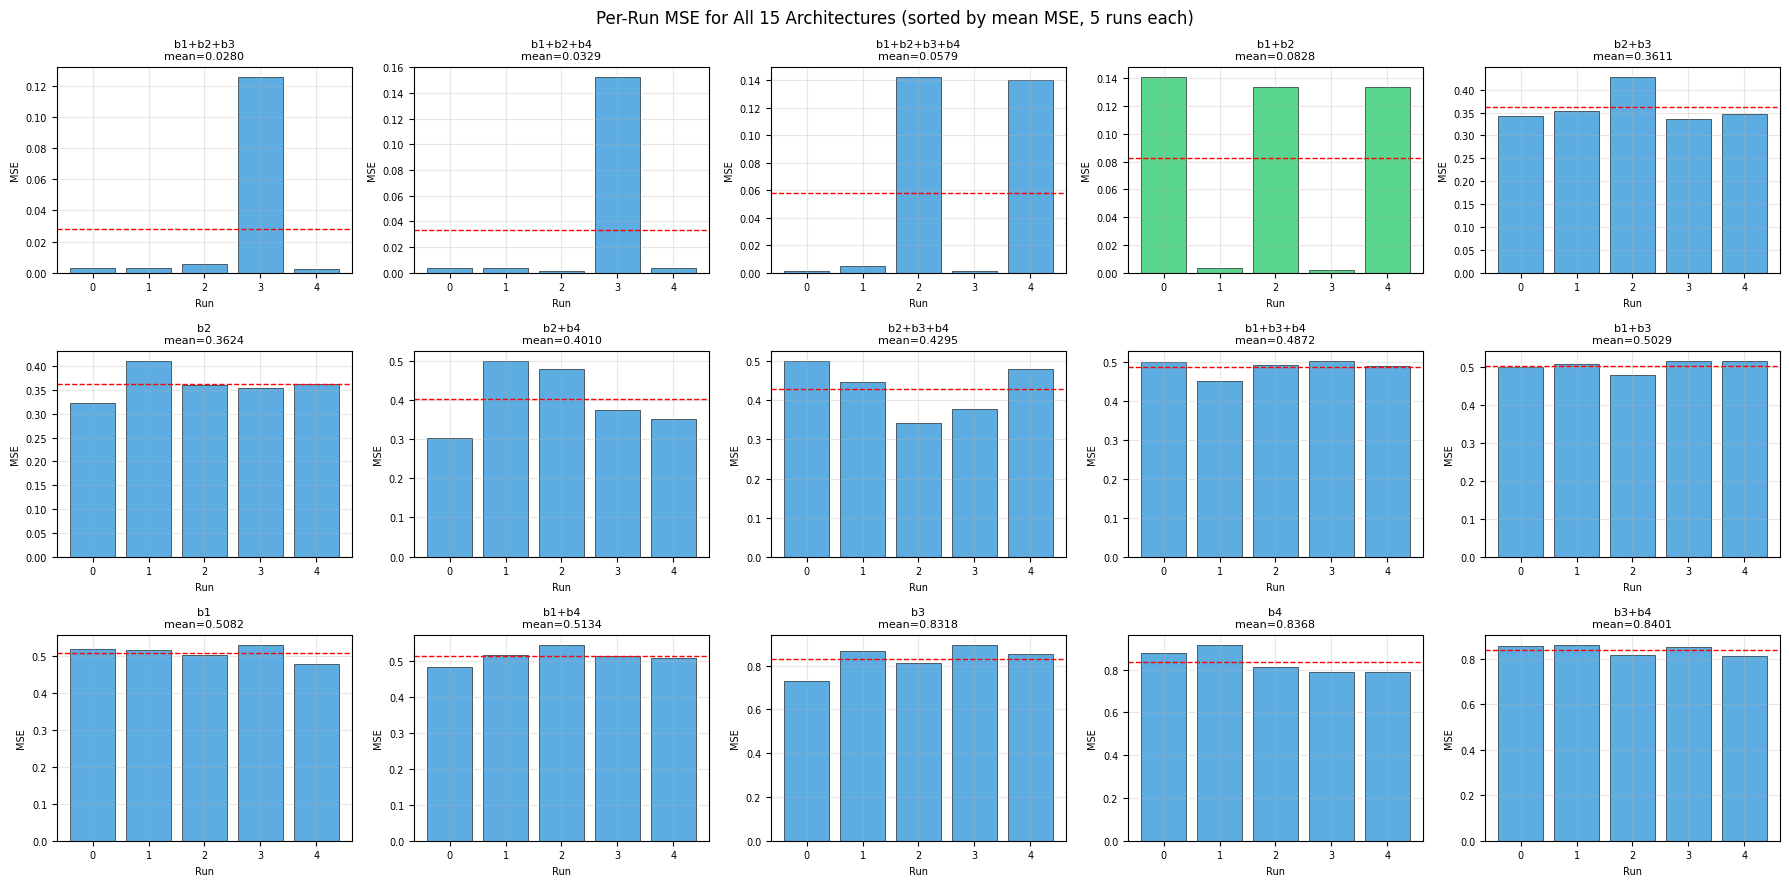

In [33]:
fig, axes = plt.subplots(3, 5, figsize=(18, 9))
axes = axes.flatten()

for ax, r in zip(axes, sorted_results):
    color = '#2ecc71' if r['is_ground_truth'] else '#3498db'
    ax.bar(range(N_RUNS), r['run_mses'], color=color, alpha=0.8, edgecolor='black', linewidth=0.5)
    ax.axhline(r['mse'], color='red', linestyle='--', linewidth=1, label=f"mean={r['mse']:.4f}")
    ax.set_title(f"{r['name']}\nmean={r['mse']:.4f}", fontsize=8)
    ax.set_xlabel('Run', fontsize=7)
    ax.set_ylabel('MSE', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)

for ax in axes[len(sorted_results):]:
    ax.set_visible(False)

fig.suptitle(f'Per-Run MSE for All 15 Architectures (sorted by mean MSE, {N_RUNS} runs each)', fontsize=12)
plt.tight_layout()
plt.savefig('results_diagram/task1_all_loss_curves.png', dpi=150, bbox_inches='tight')
print("[OK] Saved: results_diagram/task1_all_loss_curves.png")
plt.show()

## Summary

### Key Findings

1. **15 non-empty subsets** of {b1, b2, b3, b4} were exhaustively evaluated.
2. The **ground truth architecture (b1+b2)** is expected to achieve the lowest MSE,
   since Task 1's reward depends only on b1 and b2.
3. Architectures that include **irrelevant blocks** (b3, b4) are expected to converge
   more slowly and with higher MSE due to unnecessary input noise.
4. Missing a **required block** (e.g. using only b1 without b2) results in high MSE
   because the model cannot capture the full reward signal.

### Next Steps

- Extend the same search to Task 2 and Task 3
- Combine per-task search results into a joint multi-task architecture
- Investigate smarter search strategies (Bayesian optimization, etc.)